# Generación de datos sintéticos con la librería `andi_datasets`

## Objetivo general

El objetivo de este archivo es familiarizarse con la librería `andi_datasets`, utilizada para generar datos sintéticos a partir de modelos estocásticos que pueden interpretarse como variaciones del movimiento browniano.

Estos modelos permiten simular trayectorias con distintos comportamientos de difusión anómala, lo que resulta útil para analizar y comprender mejor este tipo de datos antes de aplicar métodos de detección.

En particular, en este archivo se pretende:

1. Cargar y utilizar la librería `andi_datasets`.  
2. Examinar cómo se generan las trayectorias sintéticas.
3. Observar la influencia del exponente de difusión anómala en la dinámica de las trayectorias.  
4. Realizar ejemplos numéricos sencillos para interpretar el comportamiento de los datos.  
5. Construir casos básicos relacionados con la Tarea 3.

Este análisis constituye una etapa inicial de exploración, necesaria para comprender la estructura de los datos y preparar el trabajo posterior.

---

## Contexto teórico

Los datos generados con la librería `andi_datasets` provienen de modelos estocásticos que extienden el movimiento browniano clásico. A diferencia de la difusión normal, en estos procesos la dispersión de la partícula no evoluciona siempre de la misma manera con el tiempo.

Una magnitud fundamental para describir este comportamiento es la **mean squared displacement (MSD)**, que mide el desplazamiento medio cuadrático en función del tiempo:

$$
\mathrm{MSD}(t) = \left\langle (x(t) - x(0))^2 \right\rangle
$$

En procesos de difusión anómala, esta cantidad suele seguir una ley de potencia de la forma:

$$
\mathrm{MSD}(t) \propto t^\alpha
$$

donde el exponente $\alpha$ caracteriza el tipo de difusión observado:

- $\alpha = 1$: difusión normal, correspondiente al movimiento browniano clásico,  
- $\alpha < 1$: subdifusión, asociada a una propagación más lenta,  
- $\alpha > 1$: superdifusión, asociada a una propagación más rápida o con mayor persistencia en el movimiento.

---

## Modelos considerados

La librería permite generar trayectorias a partir de distintos modelos estocásticos representativos de la difusión anómala, entre ellos:

- CTRW (Continuous Time Random Walk).
- ATTM (Annealed Transient Time Model). 
- FBM (Fractional Brownian Motion).  
- LW (Lévy Walk). 
- SBM (Scaled Brownian Motion).

Aunque varios de estos modelos pueden compartir un mismo exponente de difusión, los mecanismos que los producen no son los mismos. Por ello, comparar sus trayectorias resulta útil para entender mejor la diversidad de comportamientos que puede presentar la difusión anómala.

---

## Relación con la Tarea 3

En el artículo de referencia, la Tarea 3 se centra en trayectorias que presentan cambios de régimen dinámico.

Esto significa que una misma trayectoria puede estar formada por varios tramos con propiedades estadísticas diferentes. En este contexto, el problema consiste en detectar el punto de cambio y describir las características de cada segmento.

El trabajo realizado en este archivo sirve como preparación para ese objetivo, ya que permite comprender cómo se construyen los datos, qué información contienen y cómo pueden variar sus propiedades a lo largo de una trayectoria.

In [3]:
# Instalación de la librería (ejecutar solo si no está instalada)
# !pip install andi-datasets

# Importación de librerías
import numpy as np
import matplotlib.pyplot as plt
from andi_datasets.datasets_theory import datasets_theory

# Configuración de la visualización
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

## 1. Generación de datos sintéticos

La librería `andi_datasets` proporciona herramientas para simular trayectorias asociadas a distintos modelos de difusión anómala.

En particular, la clase `datasets_theory()` permite generar datos sintéticos a partir de modelos estocásticos bien definidos, como CTRW, FBM o SBM, entre otros.

Estos datos constituyen la base del análisis posterior, ya que permiten estudiar de manera controlada el comportamiento de distintos procesos de difusión, así como evaluar métodos de caracterización y segmentación de trayectorias.

In [4]:
# Inicialización del generador de datos sintéticos
dataset = datasets_theory()

Se crea una instancia de la clase `datasets_theory()`, que permite generar trayectorias sintéticas asociadas a distintos modelos de difusión anómala.

## 2. Primera prueba: generación de una trayectoria

En esta sección se genera una trayectoria sintética sencilla utilizando la librería `andi_datasets`.

Se consideran los siguientes parámetros:

- longitud de la trayectoria: $T = 100$,  
- un único modelo estocástico,  
- exponente de difusión: $\alpha = 1$,  
- modelo seleccionado: FBM (Fractional Brownian Motion), correspondiente a `models=[2]`.

Este ejemplo permite comprobar el correcto funcionamiento del generador, así como observar la estructura básica de los datos obtenidos.

In [5]:
# Generación de una trayectoria sintética
traj = dataset.create_dataset(
    T=100,            # longitud de la trayectoria
    N_models=1,       # número de modelos
    exponents=[1],    # exponente de difusión
    models=[2]        # modelo FBM
)

# Dimensión del array generado
traj.shape

(1, 102)

Se genera una trayectoria sintética utilizando los parámetros definidos anteriormente.  
El resultado se almacena en la variable `traj`, que contiene los datos de la trayectoria.

La instrucción `traj.shape` permite verificar la dimensión del array generado.

In [7]:
# Visualización de los primeros valores de la trayectoria
traj[0, :10]

array([ 2.        ,  1.        ,  0.        , -0.02371848, -0.06264006,
       -0.13380672, -0.03664754, -0.05404731, -0.12949313, -0.18127373])

Se muestran los primeros valores de la trayectoria generada.

En este caso, `traj[0, :10]` corresponde a los 10 primeros puntos de la primera trayectoria simulada. Esto permite observar de forma preliminar el comportamiento de los datos generados.

## Interpretación de la estructura de los datos

La salida generada por la función `create_dataset` presenta una estructura matricial en la que cada fila corresponde a una trayectoria simulada junto con sus parámetros asociados.

En particular, para una trayectoria dada se obtiene:

- `traj[0, 0]`: identificador del modelo estocástico utilizado.  
- `traj[0, 1]`: valor del exponente de difusión.
- `traj[0, 2:]`: valores de la trayectoria en función del tiempo.  

Esta organización permite disponer simultáneamente de la información del modelo, del parámetro dinámico y de la señal observada, lo cual resulta fundamental para tareas posteriores de análisis y clasificación.

In [9]:
# Extracción de la información de la trayectoria
model_id = traj[0, 0]   # identificador del modelo
alpha = traj[0, 1]      # exponente de difusión
x = traj[0, 2:]         # valores de la trayectoria

# Visualización de la información
print("Modelo:", model_id)
print("Alpha:", alpha)
print("Longitud de la trayectoria:", len(x))

Modelo: 2.0
Alpha: 1.0
Longitud de la trayectoria: 100


A partir de la estructura del array generado, se extraen los distintos elementos asociados a la trayectoria:

- el identificador del modelo estocástico (`model_id`),
- el exponente de difusión (`alpha`),
- y los valores de la trayectoria (`x`).

Esto permite separar claramente la información descriptiva del modelo de la señal observada, facilitando su análisis posterior.

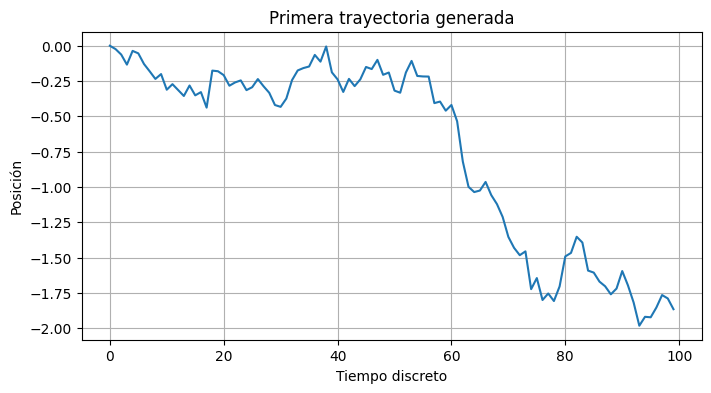

In [11]:
# Visualización de la trayectoria
plt.plot(x)
plt.title("Primera trayectoria generada")
plt.xlabel("Tiempo discreto")
plt.ylabel("Posición")
plt.show()

Se representa gráficamente la trayectoria generada en función del tiempo discreto.

Este tipo de visualización permite observar el comportamiento de la partícula a lo largo del tiempo, así como identificar posibles características del proceso de difusión, como la variabilidad o la regularidad del movimiento.

## 3. Función para calcular la MSD empírica

Para analizar la trayectoria, se calcula la *mean squared displacement* (MSD) empírica, una magnitud que describe cómo evoluciona el desplazamiento medio cuadrático con el tiempo.

In [12]:
def empirical_msd(x, max_lag=None):
    x = np.asarray(x)
    n = len(x)

    # Definición del máximo desfase
    if max_lag is None:
        max_lag = n // 4

    lags = np.arange(1, max_lag + 1)
    msd_vals = []

    # Cálculo de la MSD para cada lag
    for lag in lags:
        diffs = x[lag:] - x[:-lag]
        msd_vals.append(np.mean(diffs**2))

    return lags, np.array(msd_vals)

Este cálculo permite estimar de forma numérica la relación entre la MSD y el tiempo, lo que resulta clave para analizar el tipo de difusión presente en la trayectoria.

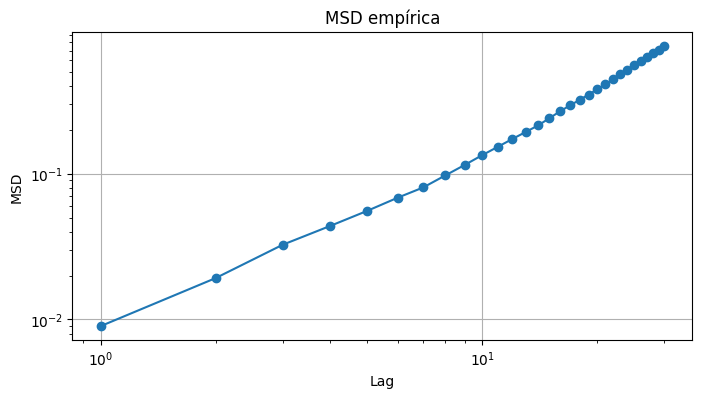

In [13]:
# Cálculo de la MSD empírica
lags, msd_vals = empirical_msd(x, max_lag=30)

# Representación en escala log-log
plt.loglog(lags, msd_vals, 'o-')
plt.title("MSD empírica")
plt.xlabel("Lag")
plt.ylabel("MSD")
plt.show()

Se calcula la MSD empírica para distintos valores de lag y se representa en escala log-log.

Este tipo de representación es especialmente útil en el contexto de la difusión anómala, ya que permite identificar relaciones de tipo potencia entre la MSD y el tiempo.

En particular, si la relación $\mathrm{MSD}(t) \propto t^\alpha$ se cumple, la gráfica en escala log-log debe aproximarse a una recta cuya pendiente corresponde al exponente $\alpha$.

## 4. Prueba 1: efecto del exponente $\alpha$

En esta sección se mantiene fijo el modelo (FBM) y se analiza el efecto de variar el exponente de difusión $\alpha$.

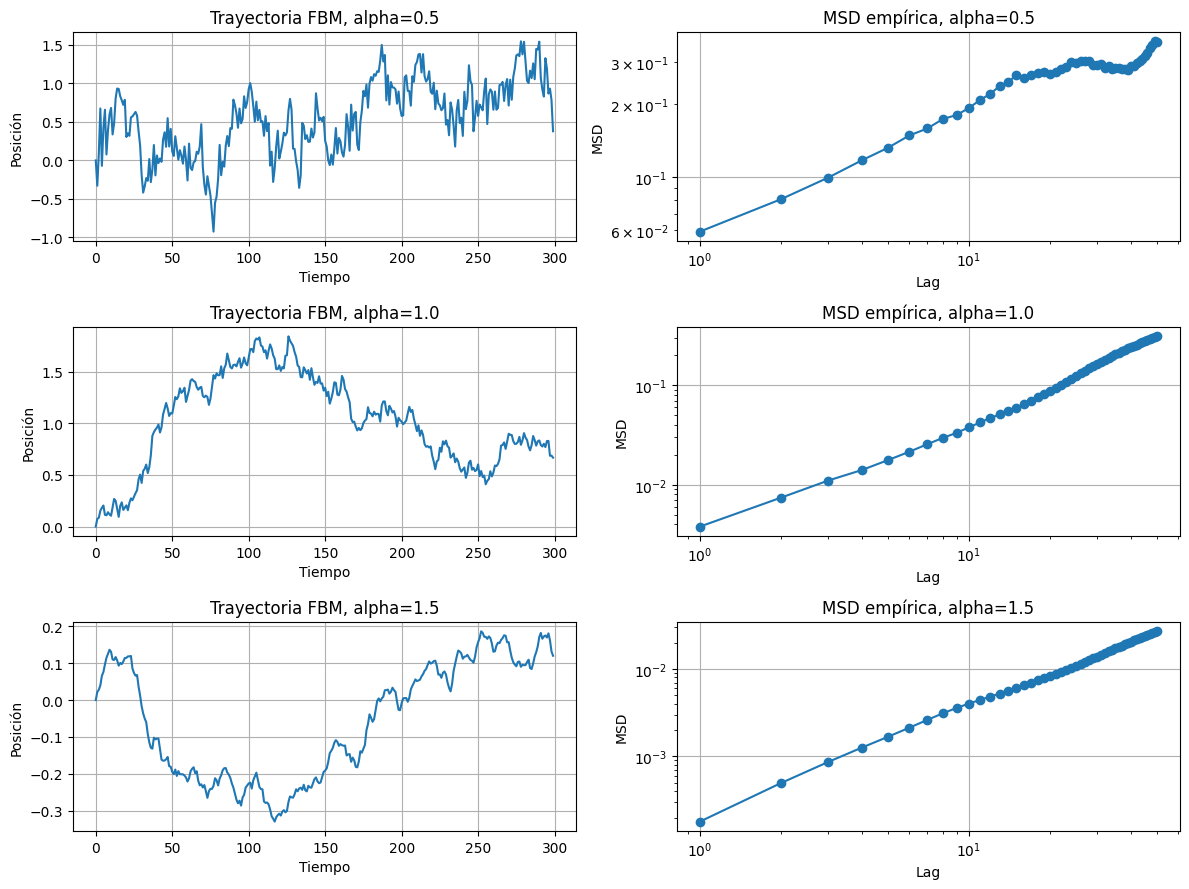

In [14]:
alphas = [0.5, 1.0, 1.5]

fig, axes = plt.subplots(len(alphas), 2, figsize=(12, 9))

for i, a in enumerate(alphas):
    traj = dataset.create_dataset(
        T=300,
        N_models=1,
        exponents=[a],
        models=[2]   # FBM
    )
    x = traj[0, 2:]

    # Trayectoria
    axes[i, 0].plot(x)
    axes[i, 0].set_title(f"Trayectoria FBM, alpha={a}")
    axes[i, 0].set_xlabel("Tiempo")
    axes[i, 0].set_ylabel("Posición")

    # MSD
    lags, msd_vals = empirical_msd(x, max_lag=50)
    axes[i, 1].loglog(lags, msd_vals, 'o-')
    axes[i, 1].set_title(f"MSD empírica, alpha={a}")
    axes[i, 1].set_xlabel("Lag")
    axes[i, 1].set_ylabel("MSD")

plt.tight_layout()
plt.show()

Se generan varias trayectorias utilizando el modelo FBM, variando el valor del exponente de difusión $\alpha$.

Para cada valor de $\alpha$, se representa la trayectoria simulada y su correspondiente MSD empírica en escala log-log, lo que permite analizar cómo cambia el comportamiento del proceso.

Se observa que:

- para $\alpha < 1$, la trayectoria presenta un comportamiento más lento (subdifusión),  
- para $\alpha = 1$, el comportamiento es compatible con una difusión normal,  
- para $\alpha > 1$, la trayectoria muestra desplazamientos más persistentes (superdifusión).  

En la representación log-log de la MSD, estas diferencias se reflejan en la pendiente de las curvas, que aumenta con el valor de $\alpha$.

## 5. Prueba 2: comparación de distintos modelos con el mismo $\alpha$

En esta sección se mantiene fijo $\alpha = 1$ y se estudia el efecto de cambiar el modelo estocástico.

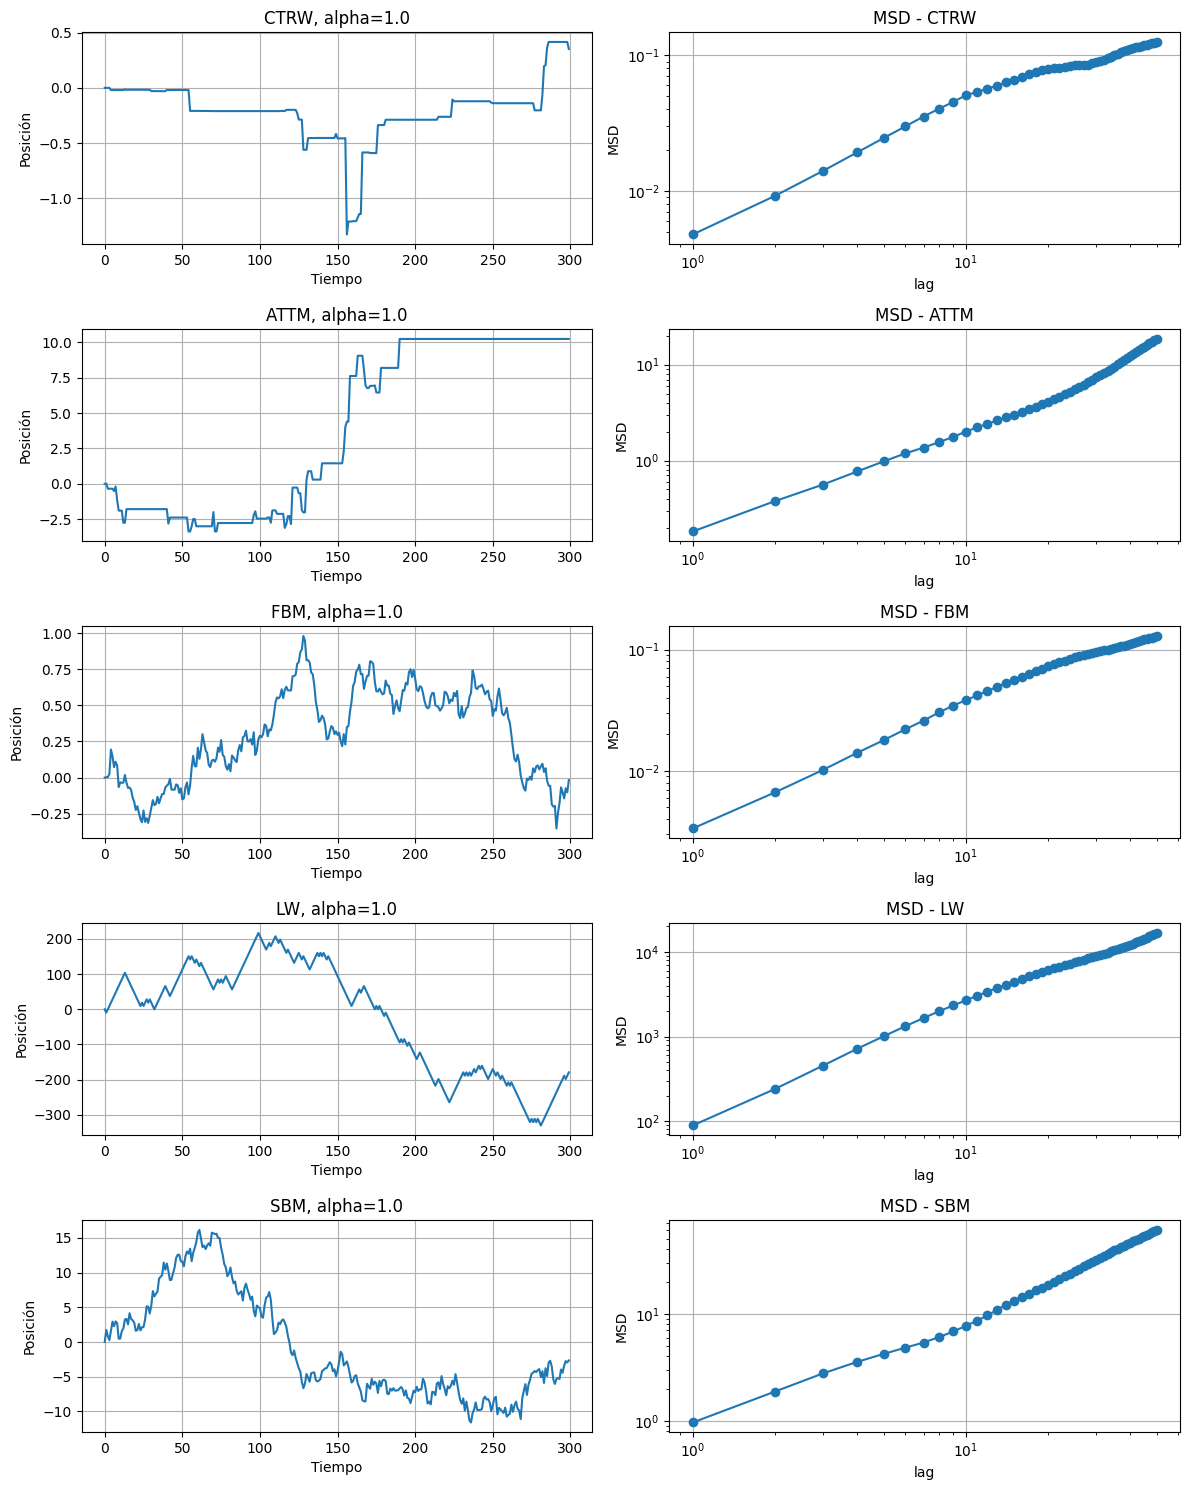

In [16]:
model_dict = {
    0: "CTRW",
    1: "ATTM",
    2: "FBM",
    3: "LW",
    4: "SBM"
}

models_to_test = [0, 1, 2, 3, 4]
alpha_fixed = 1.0

fig, axes = plt.subplots(len(models_to_test), 2, figsize=(12, 15))

for i, m in enumerate(models_to_test):
    traj = dataset.create_dataset(
        T=300,
        N_models=1,
        exponents=[alpha_fixed],
        models=[m]
    )
    x = traj[0, 2:]

    axes[i, 0].plot(x)
    axes[i, 0].set_title(f"{model_dict[m]}, alpha={alpha_fixed}")
    axes[i, 0].set_xlabel("Tiempo")
    axes[i, 0].set_ylabel("Posición")

    lags, msd_vals = empirical_msd(x, max_lag=50)
    axes[i, 1].loglog(lags, msd_vals, 'o-')
    axes[i, 1].set_title(f"MSD - {model_dict[m]}")
    axes[i, 1].set_xlabel("lag")
    axes[i, 1].set_ylabel("MSD")

plt.tight_layout()
plt.show()

Se comparan distintos modelos estocásticos fijando el mismo valor del exponente de difusión, $\alpha = 1$.

Para cada modelo, se representa la trayectoria generada y su MSD empírica. Se observa que, aunque todos presentan un comportamiento global similar en la MSD, las trayectorias pueden diferir significativamente debido a los mecanismos propios de cada modelo.

Por tanto, el valor de $\alpha$ aporta información relevante, pero no es suficiente por sí solo para distinguir entre distintos modelos de difusión anómala.

## 6. Construcción manual de una trayectoria tipo Tarea 3

La Tarea 3 consiste en estudiar trayectorias que presentan un punto de cambio (changepoint), es decir, una transición entre dos regímenes dentro de una misma trayectoria.

El objetivo es identificar la posición del cambio y caracterizar los segmentos obtenidos.

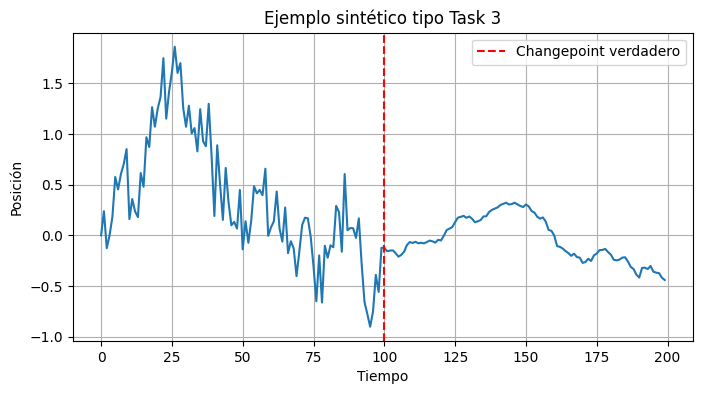

In [19]:
traj1 = dataset.create_dataset(
    T=100,
    N_models=1,
    exponents=[0.5],
    models=[2]
)

traj2 = dataset.create_dataset(
    T=100,
    N_models=1,
    exponents=[1.5],
    models=[2]
)

x1 = traj1[0, 2:]
x2 = traj2[0, 2:]

# Ajuste simple para conectar visualmente ambos segmentos
x2_shifted = x2 - x2[0] + x1[-1]

x_task3 = np.concatenate([x1, x2_shifted])
cp_true = len(x1)

plt.plot(x_task3)
plt.axvline(cp_true, color="red", linestyle="--", label="Changepoint verdadero")
plt.title("Ejemplo sintético tipo Task 3")
plt.xlabel("Tiempo")
plt.ylabel("Posición")
plt.legend()
plt.show()

Se construye una trayectoria sintética compuesta por dos segmentos con distintos regímenes de difusión.

El primer segmento corresponde a un proceso subdifusivo ($\alpha = 0.5$), mientras que el segundo corresponde a un proceso superdifusivo ($\alpha = 1.5$), ambos generados con el modelo FBM.

Para garantizar la continuidad de la trayectoria, se aplica un desplazamiento al segundo segmento, de modo que comience en el último punto del primero.

La trayectoria final se obtiene concatenando ambos segmentos, y el punto de cambio (changepoint) corresponde a la posición donde se unen las dos partes.

Este ejemplo ilustra el tipo de datos considerados en la Tarea 3, donde el objetivo es detectar automáticamente la posición del cambio y caracterizar cada uno de los segmentos.

## 7. Análisis separado de los dos segmentos

Se separa la trayectoria en dos segmentos utilizando la posición del changepoint previamente definida.

Para cada segmento, se calcula la MSD empírica y se representa en escala log-log, lo que permite analizar de forma independiente el comportamiento de cada régimen de difusión.

Se observa que las dos curvas presentan pendientes diferentes, lo que refleja la diferencia en los valores del exponente de difusión $\alpha$ utilizados en la construcción de la trayectoria.

Este resultado confirma que cada segmento corresponde a un régimen dinámico distinto y muestra cómo la MSD puede utilizarse para caracterizar cada parte de la trayectoria. Además, ilustra el principio de la Tarea 3: detectar cambios en la dinámica a partir de diferencias en las propiedades estadísticas de la señal.

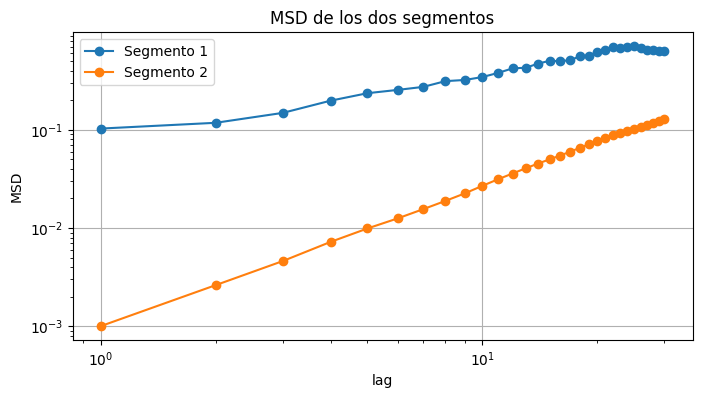

In [27]:
seg1 = x_task3[:cp_true]
seg2 = x_task3[cp_true:]

lags1, msd1 = empirical_msd(seg1, max_lag=30)
lags2, msd2 = empirical_msd(seg2, max_lag=30)

plt.loglog(lags1, msd1, 'o-', label="Segmento 1")
plt.loglog(lags2, msd2, 'o-', label="Segmento 2")
plt.title("MSD de los dos segmentos")
plt.xlabel("lag")
plt.ylabel("MSD")
plt.legend()
plt.show()

En la figura se observa que las curvas de la MSD correspondientes a los dos segmentos presentan pendientes diferentes. Esto confirma que cada segmento está asociado a un valor distinto del exponente de difusión $\alpha$, y pone de manifiesto la presencia de un cambio de régimen en la trayectoria.

## Conclusión

En este archivo se ha trabajado con la librería `andi_datasets` para generar trayectorias sintéticas basadas en modelos estocásticos que generalizan el movimiento browniano.

A través de diferentes experimentos, se ha podido observar cómo estos modelos permiten describir procesos de difusión anómala, en los que la MSD sigue una ley de potencia del tipo $\mathrm{MSD}(t) \sim t^\alpha$, siendo $\alpha$ un parámetro clave en la dinámica del sistema.

Asimismo, se han comparado distintos modelos y se ha analizado el efecto del exponente de difusión. Finalmente, se ha construido un ejemplo sencillo con un cambio de régimen, relacionado con la Tarea 3.

Este trabajo proporciona una base para entender la estructura de los datos y facilita el paso hacia el estudio de métodos de detección de cambios en trayectorias.